# Experiment: DDM vs Circuit Psychometric Curve

This notebook loads one combined sweep dataset that contains both the pure DDM and calibrated circuit results under the same task parameters, then plots both psychometric curves on the same axes.

Conventions used here:
- positive coherence means rightward evidence
- upper boundary is a right choice
- the plotted quantity is `P(right | hit)`
- `miss_fraction` is kept as a separate diagnostic


In [5]:
from __future__ import annotations

import runpy
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import curve_fit
%config InlineBackend.figure_format = 'retina'

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / "figures_code" / "notebook_setup.py"
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError("Could not locate figures_code/notebook_setup.py")

REPO_ROOT = _NOTEBOOK_SETUP["REPO_ROOT"]
REPO_ROOT


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')

## Helper Functions

The helpers below keep the task-layer logic inside the notebook:
- load one combined dataset containing both models
- summarize `P(right | hit)` and miss fraction by coherence for each model
- fit a sigmoid to each hit-conditioned psychometric curve
- plot both curves on one shared figure


In [32]:
def binomial_half_width(p_right: float, num_trials: int) -> float:
    if num_trials <= 0 or not np.isfinite(float(p_right)):
        return float("nan")
    return 1.96 * np.sqrt(float(p_right) * (1.0 - float(p_right)) / float(num_trials))


def psychometric_sigmoid(coherence: np.ndarray, bias: float, slope: float) -> np.ndarray:
    coherence = np.asarray(coherence, dtype=float)
    slope = np.maximum(float(slope), 1e-6)
    return 1.0 / (1.0 + np.exp(-(coherence - float(bias)) / slope))


def fit_psychometric_curve(summary_df: pd.DataFrame) -> dict:
    valid_df = summary_df[np.isfinite(summary_df["p_right"])].copy()
    if len(valid_df) < 3:
        raise ValueError("Need at least three coherence conditions with hits to fit the psychometric curve.")
    x = valid_df["coherence"].to_numpy(dtype=float)
    y = np.clip(valid_df["p_right"].to_numpy(dtype=float), 1e-4, 1.0 - 1e-4)
    params, covariance = curve_fit(
        psychometric_sigmoid,
        x,
        y,
        p0=(0.0, 0.2),
        bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
        maxfev=10000,
    )
    coherence_fine = np.linspace(float(np.min(x)), float(np.max(x)), 400)
    fitted_p_right = psychometric_sigmoid(coherence_fine, *params)
    return {
        "bias": float(params[0]),
        "slope": float(params[1]),
        "covariance": covariance,
        "coherence_fine": coherence_fine,
        "fitted_p_right": fitted_p_right,
    }


def summarize_model_sweep(*, model_name: str, coherence_values: np.ndarray, choice: np.ndarray, hit_boundary: np.ndarray, rt_ms: np.ndarray, drift_gain: float) -> pd.DataFrame:
    rows = []
    for index, coherence in enumerate(np.asarray(coherence_values, dtype=float)):
        choice_row = np.asarray(choice[index])
        hit_row = np.asarray(hit_boundary[index], dtype=bool)
        rt_row = np.asarray(rt_ms[index], dtype=float)
        num_hit = int(np.sum(hit_row))
        p_right = float(np.mean(choice_row[hit_row] == 1)) if num_hit > 0 else float("nan")
        hit_fraction = float(np.mean(hit_row))
        rows.append(
            {
                "model": str(model_name),
                "coherence": float(coherence),
                "drift_rate": float(drift_gain) * float(coherence),
                "p_right": p_right,
                "num_hit": num_hit,
                "miss_fraction": 1.0 - hit_fraction,
                "hit_fraction": hit_fraction,
                "mean_rt_ms": float(np.nanmean(rt_row)) if np.any(hit_row) else float("nan"),
                "ci_half_width": binomial_half_width(p_right, num_hit),
            }
        )
    return pd.DataFrame(rows).sort_values("coherence").reset_index(drop=True)


def load_combined_psychometric_dataset(dataset_path: Path) -> tuple[dict, dict[str, pd.DataFrame], dict[str, np.ndarray]]:
    dataset_path = Path(dataset_path)
    config = json.loads(dataset_path.with_name("config.json").read_text())
    with np.load(dataset_path, allow_pickle=False) as data:
        model_names = [str(name) for name in data["model_names"].tolist()]
        coherence_values = np.asarray(data["coherence_values"], dtype=float)
        choice = np.asarray(data["choice"])
        hit_boundary = np.asarray(data["hit_boundary"])
        rt_ms = np.asarray(data["rt_ms"], dtype=float)
        time_ms = np.asarray(data["time_ms"], dtype=float)
        final_x = np.asarray(data["final_x"], dtype=float)
        metadata = json.loads(str(data["metadata_json"].item()))

    summary_by_model = {}
    raw_by_model = {}
    for model_index, model_name in enumerate(model_names):
        summary_by_model[model_name] = summarize_model_sweep(
            model_name=model_name,
            coherence_values=coherence_values,
            choice=choice[model_index],
            hit_boundary=hit_boundary[model_index],
            rt_ms=rt_ms[model_index],
            drift_gain=float(config["drift_gain"]),
        )
        raw_by_model[model_name] = {
            "choice": choice[model_index],
            "hit_boundary": hit_boundary[model_index],
            "rt_ms": rt_ms[model_index],
            "time_ms": time_ms[model_index],
            "final_x": final_x[model_index],
        }

    config["metadata"] = metadata
    return config, summary_by_model, raw_by_model


def plot_psychometric_comparison(ddm_summary_df: pd.DataFrame, ddm_fit: dict, circuit_summary_df: pd.DataFrame, circuit_fit: dict, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.4, 4.4))
    else:
        fig = ax.figure

    ax.errorbar(
        ddm_summary_df["coherence"],
        ddm_summary_df["p_right"],
        yerr=ddm_summary_df["ci_half_width"],
        fmt="o",
        color="#1d4ed8",
        ecolor="#93c5fd",
        elinewidth=1.2,
        capsize=3.0,
        markersize=6.0,
        label="DDM data",
    )
    ax.plot(ddm_fit["coherence_fine"], ddm_fit["fitted_p_right"], color="#1d4ed8", linewidth=2.0, label="DDM fit")

    ax.errorbar(
        circuit_summary_df["coherence"],
        circuit_summary_df["p_right"],
        yerr=circuit_summary_df["ci_half_width"],
        fmt="s",
        color="#b91c1c",
        ecolor="#fca5a5",
        elinewidth=1.2,
        capsize=3.0,
        markersize=5.5,
        label="Circuit data",
    )
    ax.plot(circuit_fit["coherence_fine"], circuit_fit["fitted_p_right"], color="#b91c1c", linewidth=2.0, label="Circuit fit")

    ax.axhline(0.5, color="black", linestyle="--", linewidth=1.0)
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0)
    ax.set_xlabel("Motion coherence", fontsize=16)
    ax.set_ylabel("Percent Right", fontsize=16)
    ax.set_xticks([-1, -0.5, 0, 0.5, 1], ["-1", "-0.5", "0", "0.5", "1"], fontsize=12)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ["0", "0.2", "0.4", "0.6", "0.8", "1"], fontsize=12)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(False)
    ax.set_title("DDM vs circuit psychometric curve", fontsize=16)
    ax.legend(frameon=False, loc="upper left", fontsize=10)
    return fig, ax


## Combined Dataset Path

This notebook now expects one combined run folder containing the merged DDM+circuit outputs.


In [23]:
COMBINED_RUN_ROOT = REPO_ROOT / "results" / "psychometric" / "9_coh_200_trials_each"
COMBINED_DATASET_PATH = COMBINED_RUN_ROOT / "dataset.npz"

combined_config, summary_by_model, raw_by_model = load_combined_psychometric_dataset(COMBINED_DATASET_PATH)
ddm_summary_df = summary_by_model["ddm"]
circuit_summary_df = summary_by_model["circuit"]

ddm_fit = fit_psychometric_curve(ddm_summary_df)
circuit_fit = fit_psychometric_curve(circuit_summary_df)

display(ddm_summary_df)
display(circuit_summary_df)

print(f"DDM worst miss fraction: {ddm_summary_df['miss_fraction'].max():.4f}")
print(f"Circuit worst miss fraction: {circuit_summary_df['miss_fraction'].max():.4f}")
print(f"DDM fit: bias={ddm_fit['bias']:.4f}, slope={ddm_fit['slope']:.4f}")
print(f"Circuit fit: bias={circuit_fit['bias']:.4f}, slope={circuit_fit['slope']:.4f}")


,model,coherence,drift_rate,p_right,num_hit,miss_fraction,hit_fraction,mean_rt_ms,ci_half_width
0,ddm,-1.000,-1.000,0.000000,200,0.000,1.000,485.875000,0.000000
1,ddm,-0.500,-0.500,0.005525,181,0.095,0.905,870.082873,0.010799
2,ddm,-0.250,-0.250,0.088889,135,0.325,0.675,1182.703704,0.048006
3,ddm,-0.125,-0.125,0.198198,111,0.445,0.555,1170.540541,0.074161
4,ddm,0.000,0.000,0.544444,90,0.550,0.450,1124.944444,0.102892
5,ddm,0.125,0.125,0.813559,118,0.410,0.590,1169.872881,0.070272
6,ddm,0.250,0.250,0.969697,132,0.340,0.660,1166.439394,0.029244
7,ddm,0.500,0.500,0.989362,188,0.060,0.940,846.223404,0.014665
8,ddm,1.000,1.000,1.000000,200,0.000,1.000,515.950000,0.000000


,model,coherence,drift_rate,p_right,num_hit,miss_fraction,hit_fraction,mean_rt_ms,ci_half_width
0,circuit,-1.000,-1.000,0.000000,200,0.000,1.000,482.685000,0.000000
1,circuit,-0.500,-0.500,0.000000,187,0.065,0.935,883.449198,0.000000
2,circuit,-0.250,-0.250,0.029197,137,0.315,0.685,1130.810219,0.028192
3,circuit,-0.125,-0.125,0.148936,94,0.530,0.470,1151.659574,0.071974
4,circuit,0.000,0.000,0.462500,80,0.600,0.400,1186.337500,0.109259
5,circuit,0.125,0.125,0.781250,96,0.520,0.480,1210.364583,0.082697
6,circuit,0.250,0.250,0.916031,131,0.345,0.655,1160.061069,0.047494
7,circuit,0.500,0.500,0.989011,182,0.090,0.910,938.296703,0.015146
8,circuit,1.000,1.000,1.000000,200,0.000,1.000,552.440000,0.000000


DDM worst miss fraction: 0.5500
Circuit worst miss fraction: 0.6000
DDM fit: bias=-0.0120, slope=0.0881
Circuit fit: bias=0.0170, slope=0.0854


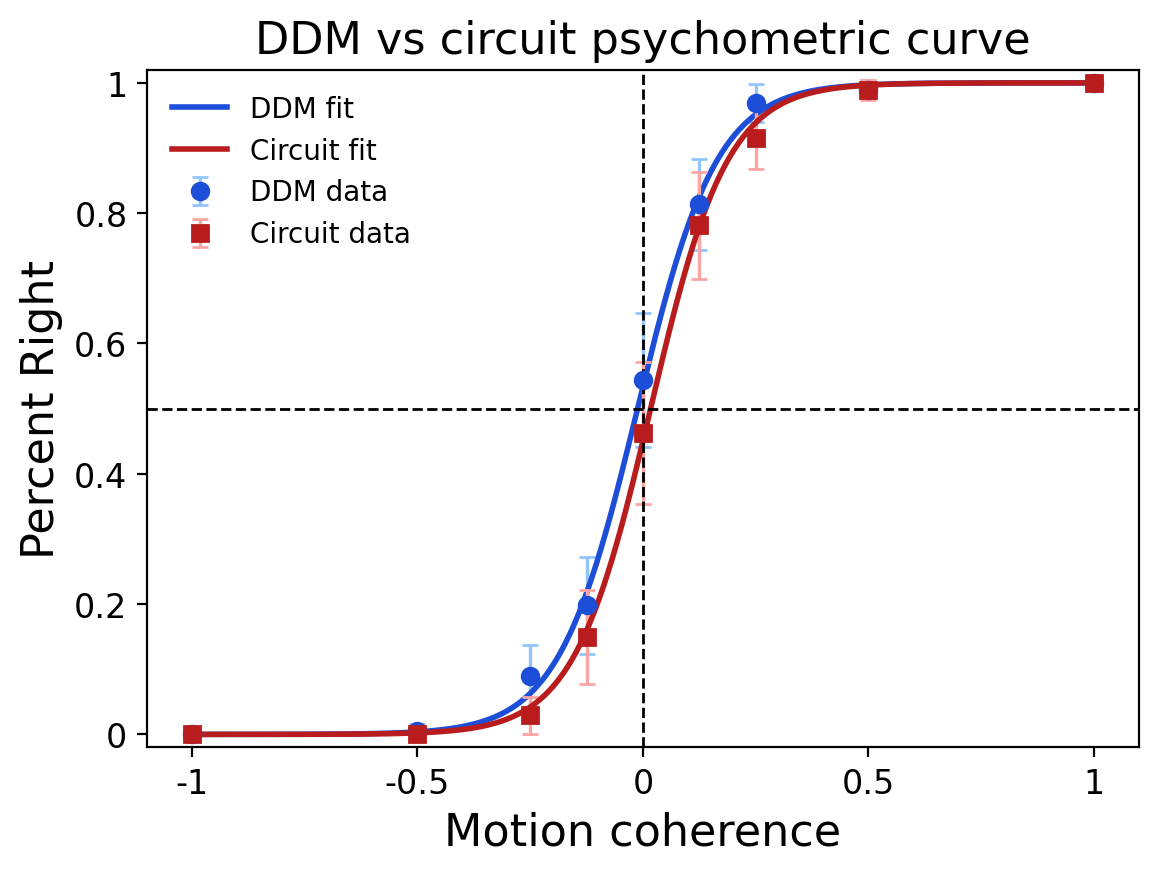

Saved psychometric comparison figure to /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/supp/ddm_circuit_psychometric_curve.png


In [33]:
fig, ax = plot_psychometric_comparison(ddm_summary_df, ddm_fit, circuit_summary_df, circuit_fit)
#OUTPUT_PATH = REPO_ROOT / "figures" / "supp" / "ddm_circuit_psychometric_curve.png"
#OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
#fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")

plt.show()
print(f"Saved psychometric comparison figure to {OUTPUT_PATH}")


## Notes

- This notebook no longer loads separate DDM and circuit run folders.
- It reads one combined dataset and splits it by `model_names` internally.
- The plotted psychometric curves still use `P(right | hit)`.
- If you regenerate the combined run under a different folder, only the combined-run path cell needs to change.
